# Temporary: tissue / quality — what we remove

**Removal criteria (no high white):**
1. **Solid-color** (very low gray std → no texture).
2. **High black** (pure black patches; typically 2 in sample).
3. **Low tissue (combined mix):** saturation OR local variance; Otsu-normalized on edge cases. Patches with tissue % final below threshold are removed.

Plots: solid-color sample, "would remove" by combined (24), **summary (total + more patches)**, and most tissue (combined) for comparison.

In [26]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pcam-master"))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, _), _, _ = load_data(data_dir=DATA_DIR)
print("Loaded train:", train_x.shape)

Loaded train: (262144, 96, 96, 3)


In [27]:
def otsu_threshold_01(gray):
    """Otsu threshold for [0,1] float grayscale. Returns threshold in [0,1]."""
    flat = np.asarray(gray).ravel().astype(np.float64)
    hist, _ = np.histogram(flat, bins=256, range=(0, 1))
    bin_centers = (np.arange(256) + 0.5) / 256.0
    total = hist.sum()
    if total == 0:
        return 0.5
    p = hist / total
    sigma_b_sq_max = -1.0
    best_t = 0.5
    for t in range(1, 255):
        w0, w1 = p[:t].sum(), p[t:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (p[:t] * bin_centers[:t]).sum() / w0
        mu1 = (p[t:] * bin_centers[t:]).sum() / w1
        sigma_b_sq = w0 * w1 * (mu0 - mu1) ** 2
        if sigma_b_sq > sigma_b_sq_max:
            sigma_b_sq_max = sigma_b_sq
            best_t = bin_centers[t]
    return best_t

def saturation_from_rgb(rgb):
    """RGB [0,1], return S per pixel (HSV saturation). max/min over last axis."""
    mx, mn = rgb.max(axis=2), rgb.min(axis=2)
    return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)

def local_variance_map(gray, win=11):
    """Local variance in window; gray [0,1]."""
    m = uniform_filter(gray.astype(np.float64), size=win, mode='nearest')
    m2 = uniform_filter((gray.astype(np.float64))**2, size=win, mode='nearest')
    return m2 - m**2

def tissue_pct_otsu_normalized(gray):
    """Contrast-normalize (5th-95th stretch to [0,1]) then Otsu; tissue = fraction below threshold."""
    p5, p95 = np.percentile(gray, 5), np.percentile(gray, 95)
    span = max(p95 - p5, 1e-8)
    g = np.clip((gray - p5) / span, 0, 1)
    t = otsu_threshold_01(g)
    return float(np.sum(g < t) / g.size)

n_sample = min(20000, len(train_x))
np.random.seed(42)
indices = np.random.choice(len(train_x), size=n_sample, replace=False)

HIGH_WHITE_THRESHOLD = 0.75
HIGH_BLACK_THRESHOLD = 0.5
SOLID_COLOR_STD_THRESHOLD = 0.04
LOW_TISSUE_OTSU_THRESHOLD = 0.20
SAT_THRESHOLD = 0.12
VAR_THRESHOLD = 0.003
EDGE_LO, EDGE_HI = 0.12, 0.45
LOW_TISSUE_COMBINED_THRESHOLD = 0.35  # relaxed: remove more (was 0.20); catch borderline low-tissue
LOCAL_VAR_WIN = 11

rows = []
for i in indices:
    patch = np.asarray(train_x[i]).astype(np.float64)
    if patch.max() > 1.0:
        patch = patch / 255.0
    patch = np.clip(patch, 0, 1)
    gray = patch.mean(axis=2)
    n_elems = patch.size
    n_px = gray.size
    ratio_white = float(np.sum(patch >= 0.9) / n_elems)
    ratio_black = float(np.sum(patch <= 0.1) / n_elems)
    gray_std = float(np.std(gray))
    otsu_t = otsu_threshold_01(gray)
    tissue_pct_otsu = float(np.sum(gray < otsu_t) / n_px)
    solid_color = 1 if gray_std < SOLID_COLOR_STD_THRESHOLD else 0
    sat = saturation_from_rgb(patch)
    tissue_pct_sat = float(np.sum(sat > SAT_THRESHOLD) / n_px)
    var_map = local_variance_map(gray, win=LOCAL_VAR_WIN)
    tissue_pct_var = float(np.sum(var_map > VAR_THRESHOLD) / n_px)
    tissue_pct_combined = float(np.sum((sat > SAT_THRESHOLD) | (var_map > VAR_THRESHOLD)) / n_px)
    if EDGE_LO < tissue_pct_combined < EDGE_HI:
        otsu_norm = tissue_pct_otsu_normalized(gray)
        tissue_pct_final = max(tissue_pct_combined, otsu_norm)
    else:
        tissue_pct_final = tissue_pct_combined
    rows.append((i, ratio_white, ratio_black, gray_std, tissue_pct_otsu, solid_color,
                 tissue_pct_sat, tissue_pct_var, tissue_pct_combined, tissue_pct_final))

data = np.array(rows)
idx_col, w_col, b_col = 0, 1, 2
std_col, tissue_col, solid_col = 3, 4, 5
sat_col, var_col, comb_col, final_col = 6, 7, 8, 9

solid_color_mask = data[:, solid_col] == 1
solid_color_patches = data[solid_color_mask]
high_white = data[data[:, w_col] >= HIGH_WHITE_THRESHOLD]
high_black = data[data[:, b_col] >= HIGH_BLACK_THRESHOLD]
low_tissue_otsu = data[data[:, tissue_col] < LOW_TISSUE_OTSU_THRESHOLD]
low_tissue_combined = data[data[:, final_col] < LOW_TISSUE_COMBINED_THRESHOLD]

print("Pipeline: 1) Solid-color. 2) High white/black. 3) Low tissue (combined = sat OR var; Otsu-norm for edge cases).")
print(f"Solid-color: {len(solid_color_patches)}  |  High white: {len(high_white)}  |  High black: {len(high_black)}")
print(f"Low tissue (combined, final < {LOW_TISSUE_COMBINED_THRESHOLD}): {len(low_tissue_combined)} would remove")
print(f"Tissue % combined range: [{data[:, comb_col].min():.2f}, {data[:, comb_col].max():.2f}]  final: [{data[:, final_col].min():.2f}, {data[:, final_col].max():.2f}]")

C:\Users\tamer\AppData\Local\Temp\ipykernel_2612\4044373834.py:27: RuntimeWarning: invalid value encountered in divide
  return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)


Pipeline: 1) Solid-color. 2) High white/black. 3) Low tissue (combined = sat OR var; Otsu-norm for edge cases).
Solid-color: 160  |  High white: 1054  |  High black: 2
Low tissue (Otsu only): 2660  |  Low tissue (combined, would remove): 349
Tissue % combined range: [0.00, 1.00]  final: [0.00, 1.00]


## Solid-color patches (remove first)

Patches with very low intensity variance (gray_std < threshold) — almost no texture; solid purple, black, white, or single hue. Removing these first avoids misclassifying them by white/black ratio alone.

C:\Users\tamer\AppData\Local\Temp\ipykernel_2612\352697828.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lab = "abnormal" if int(train_y[idx]) == 1 else "normal"


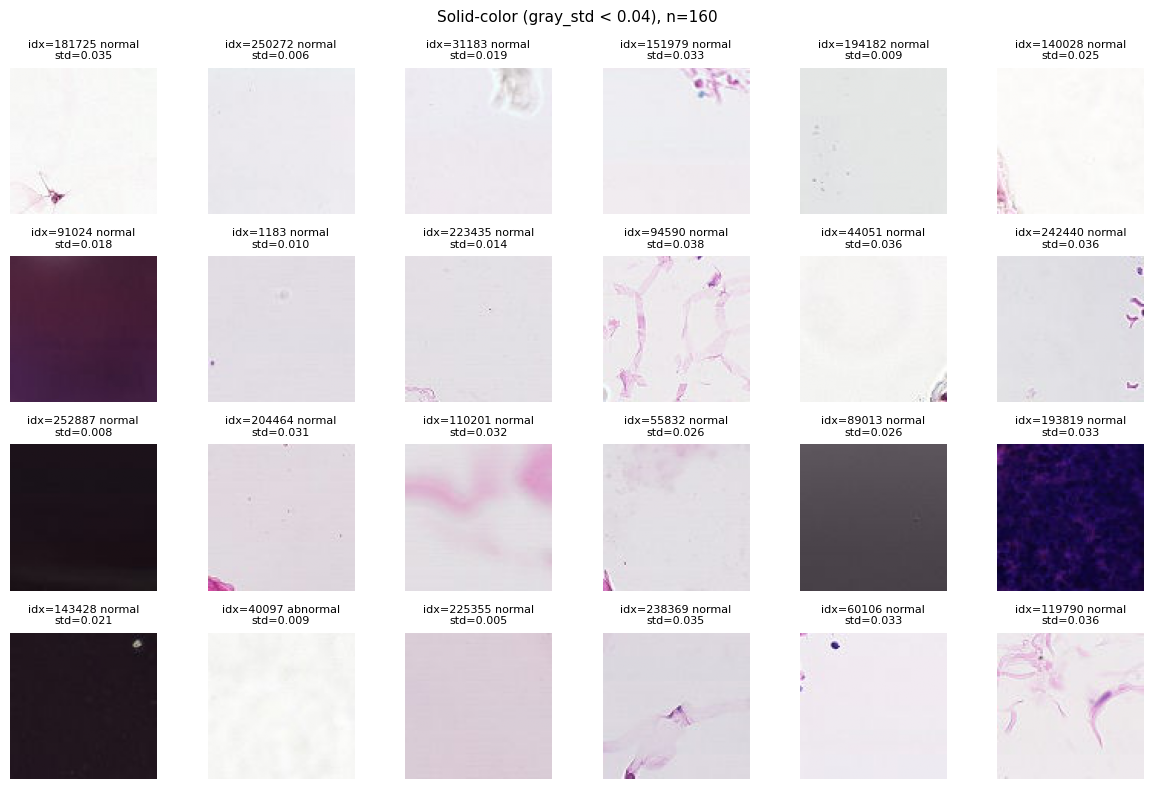

In [28]:
# Run the computation cell above first (defines data, solid_color_patches, std_col, etc.)
try:
    _ = solid_color_patches
except NameError:
    raise NameError("Run the cell above first (the one with otsu_threshold_01 and 'rows = []').")
n_show = 24
solid_to_show = solid_color_patches[:min(n_show, len(solid_color_patches))]
fig_s, axes_s = plt.subplots(4, 6, figsize=(12, 8))
for k in range(24):
    ax = axes_s.flat[k]
    if k < len(solid_to_show):
        idx = int(solid_to_show[k, idx_col])
        patch = np.asarray(train_x[idx])
        if patch.max() > 1.0: patch = np.clip(patch / 255.0, 0, 1)
        ax.imshow(patch)
        gs = solid_to_show[k, std_col]
        lab = "abnormal" if int(train_y[idx]) == 1 else "normal"
        ax.set_title(f"idx={idx} {lab}\nstd={gs:.3f}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Solid-color (gray_std < {SOLID_COLOR_STD_THRESHOLD}), n={len(solid_color_patches)}", fontsize=11)
plt.tight_layout()
plt.show()

*(Removed: high white ratio section. We no longer remove by high white; only solid-color, high black, and low tissue combined.)*

In [29]:
# (Plot removed: we no longer remove by high white ratio.)

*(Removed: high black plot. We still remove the 2 high-black patches; see summary cell.)*

In [30]:
# (Plot removed: high black — only 2 patches; see summary cell.)

*(Removed: most tissue by Otsu only. We use combined method below.)*

In [31]:
# (Plot removed: we use combined method for "most tissue" below.)

*(Removed: low tissue by Otsu only. We use combined method below.)*

In [32]:
# (Plot removed: we use combined method for "would remove" below.)

## Would remove: combined method (saturation OR local variance + Otsu-norm on edge cases)

Patches that would be **removed** by the combined tissue rule: **tissue % final** < threshold. Final = (saturated OR high local variance); for edge cases (combined in [0.12, 0.45]) we use the max of combined and contrast-normalized Otsu. Below: the **least low** of those removed (highest tissue % among removed).

C:\Users\tamer\AppData\Local\Temp\ipykernel_2612\2994747943.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lab = "abnormal" if int(train_y[idx]) == 1 else "normal"


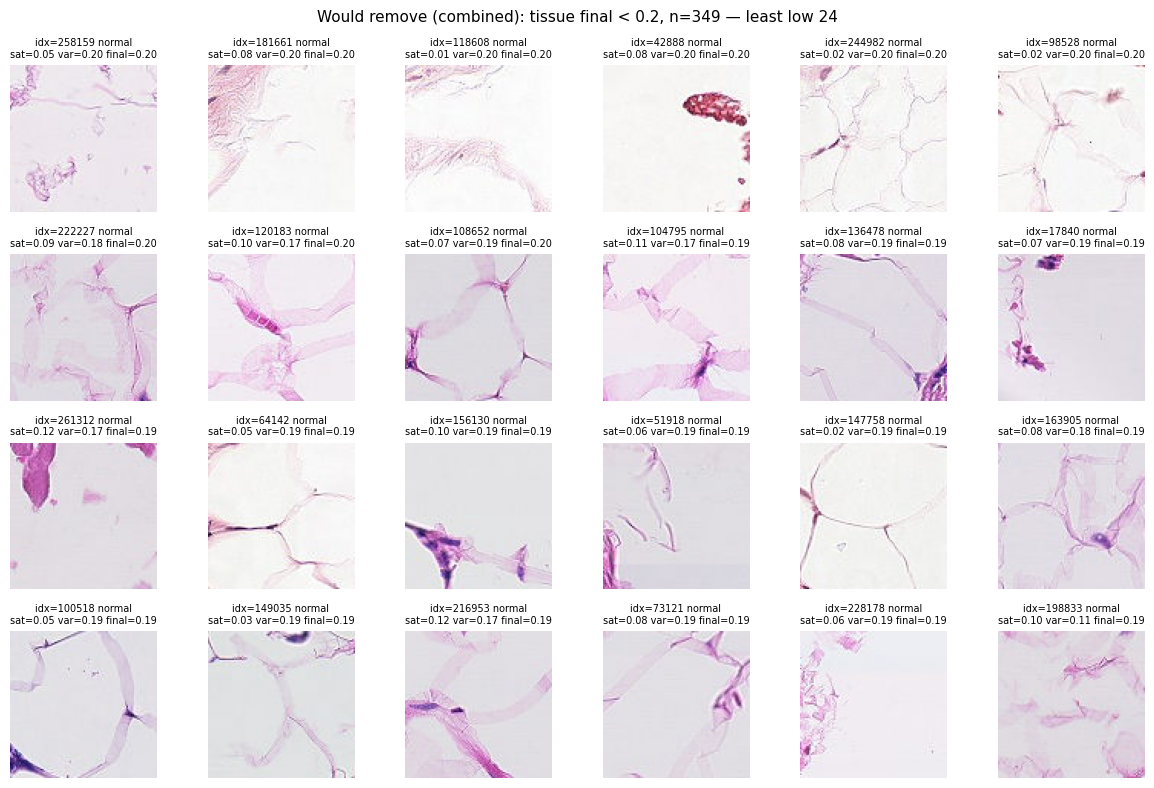

In [33]:
# Least low of removed (combined method)
low_comb_sorted = low_tissue_combined[np.argsort(-low_tissue_combined[:, final_col])]
to_show_comb = low_comb_sorted[:min(24, len(low_comb_sorted))]
fig_comb, axes_comb = plt.subplots(4, 6, figsize=(12, 8))
for k in range(24):
    ax = axes_comb.flat[k]
    if k < len(to_show_comb):
        idx = int(to_show_comb[k, idx_col])
        patch = np.asarray(train_x[idx])
        if patch.max() > 1.0: patch = np.clip(patch / 255.0, 0, 1)
        ax.imshow(patch)
        sat_p, var_p, comb_p, fin_p = to_show_comb[k, sat_col], to_show_comb[k, var_col], to_show_comb[k, comb_col], to_show_comb[k, final_col]
        lab = "abnormal" if int(train_y[idx]) == 1 else "normal"
        ax.set_title(f"idx={idx} {lab}\nsat={sat_p:.2f} var={var_p:.2f} final={fin_p:.2f}", fontsize=7)
    ax.axis("off")
plt.suptitle(f"Would remove (combined): tissue final < {LOW_TISSUE_COMBINED_THRESHOLD}, n={len(low_tissue_combined)} — least low 24", fontsize=11)
plt.tight_layout()
plt.show()

## Summary: total removed and more patches (combined mix)

Union of all removed indices: solid-color + high black + low tissue (combined). Below: total count and a larger sample of patches that would be removed.

Removal breakdown (in sample):
  Solid-color:        160
  High black:          2
  Low tissue (combined): 349
  Union (total would remove): 370
  (Sample size: 20000 → keep 19630)


C:\Users\tamer\AppData\Local\Temp\ipykernel_2612\3244273292.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lab = "abn" if int(train_y[idx]) == 1 else "norm"


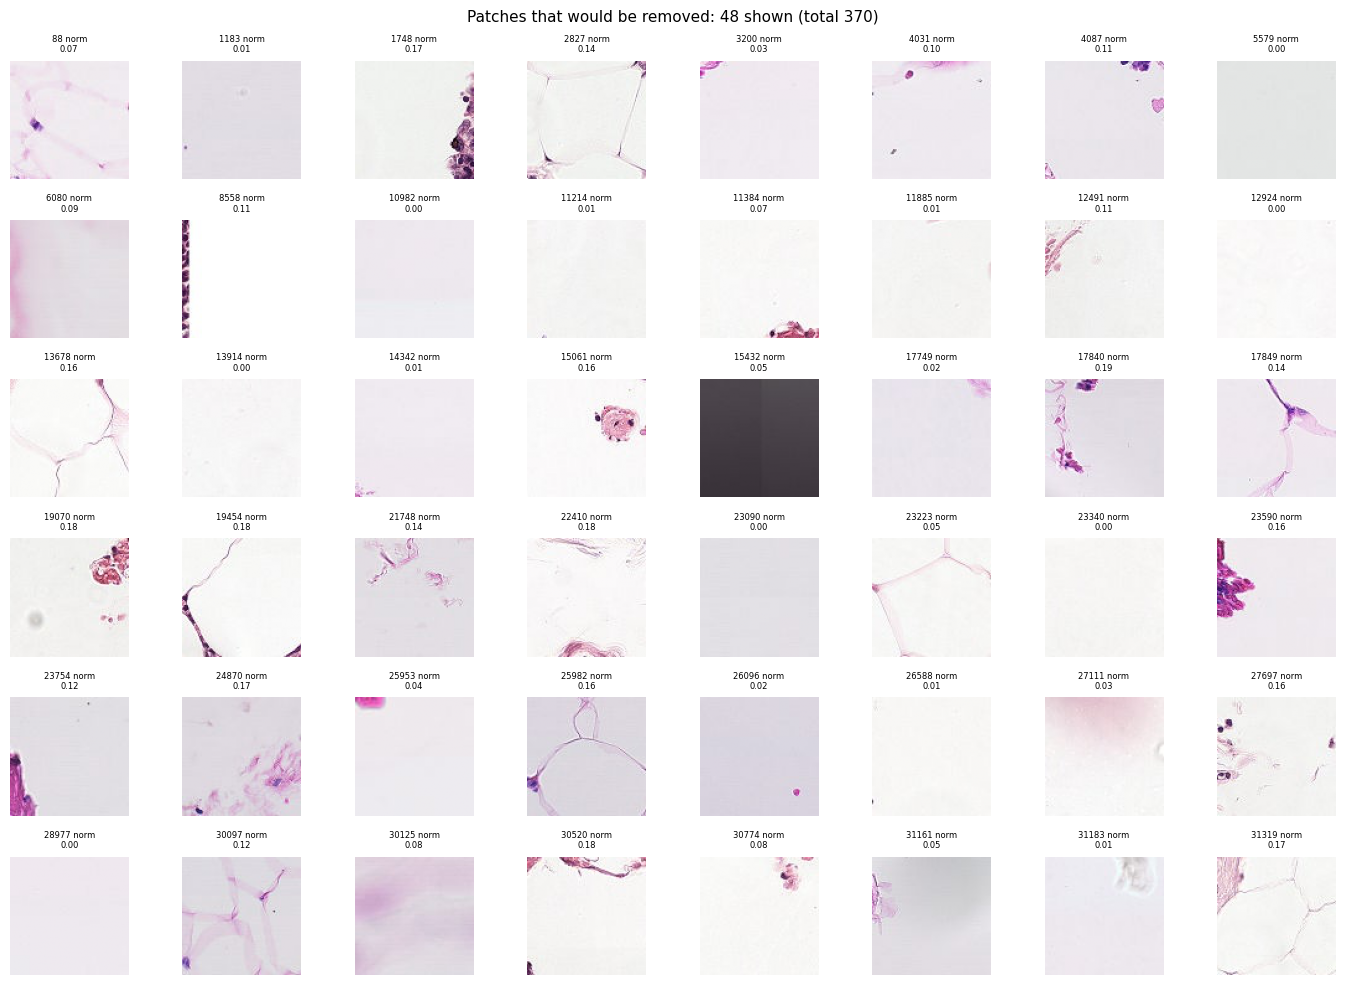

In [34]:
# Union of removed: solid-color OR high black OR low tissue (combined)
idx_remove_solid = set(data[solid_color_mask, idx_col].astype(int))
idx_remove_black = set(data[data[:, b_col] >= HIGH_BLACK_THRESHOLD, idx_col].astype(int))
idx_remove_low = set(low_tissue_combined[:, idx_col].astype(int))
idx_remove_all = idx_remove_solid | idx_remove_black | idx_remove_low

n_solid, n_black, n_low = len(idx_remove_solid), len(idx_remove_black), len(idx_remove_low)
n_total_remove = len(idx_remove_all)

print("Removal breakdown (in sample):")
print(f"  Solid-color:        {n_solid}")
print(f"  High black:          {n_black}")
print(f"  Low tissue (combined): {n_low}")
print(f"  Union (total would remove): {n_total_remove}")
print(f"  (Sample size: {n_sample} → keep {n_sample - n_total_remove})")

# Show more patches that would be removed (48 in 6x8 grid)
n_show_more = 48
remove_list = sorted(idx_remove_all)[:n_show_more]
row_inds = [np.where(data[:, idx_col] == i)[0][0] for i in remove_list]
to_show_more = data[row_inds]

nrows, ncols = 6, 8
fig_more, axes_more = plt.subplots(nrows, ncols, figsize=(14, 10))
for k in range(nrows * ncols):
    ax = axes_more.flat[k]
    if k < len(to_show_more):
        idx = int(to_show_more[k, idx_col])
        patch = np.asarray(train_x[idx])
        if patch.max() > 1.0: patch = np.clip(patch / 255.0, 0, 1)
        ax.imshow(patch)
        fin_p = to_show_more[k, final_col]
        lab = "abn" if int(train_y[idx]) == 1 else "norm"
        ax.set_title(f"{idx} {lab}\n{fin_p:.2f}", fontsize=6)
    ax.axis("off")
plt.suptitle(f"Patches that would be removed: {len(to_show_more)} shown (total {n_total_remove})", fontsize=11)
plt.tight_layout()
plt.show()

## For comparison: most tissue (combined method)

Top 24 patches by **tissue % final** (saturation OR variance, Otsu-norm on edge cases), excluding solid-color — i.e. the ones we would **keep** as having the most tissue.

C:\Users\tamer\AppData\Local\Temp\ipykernel_2612\157023218.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lab = "abnormal" if int(train_y[idx]) == 1 else "normal"


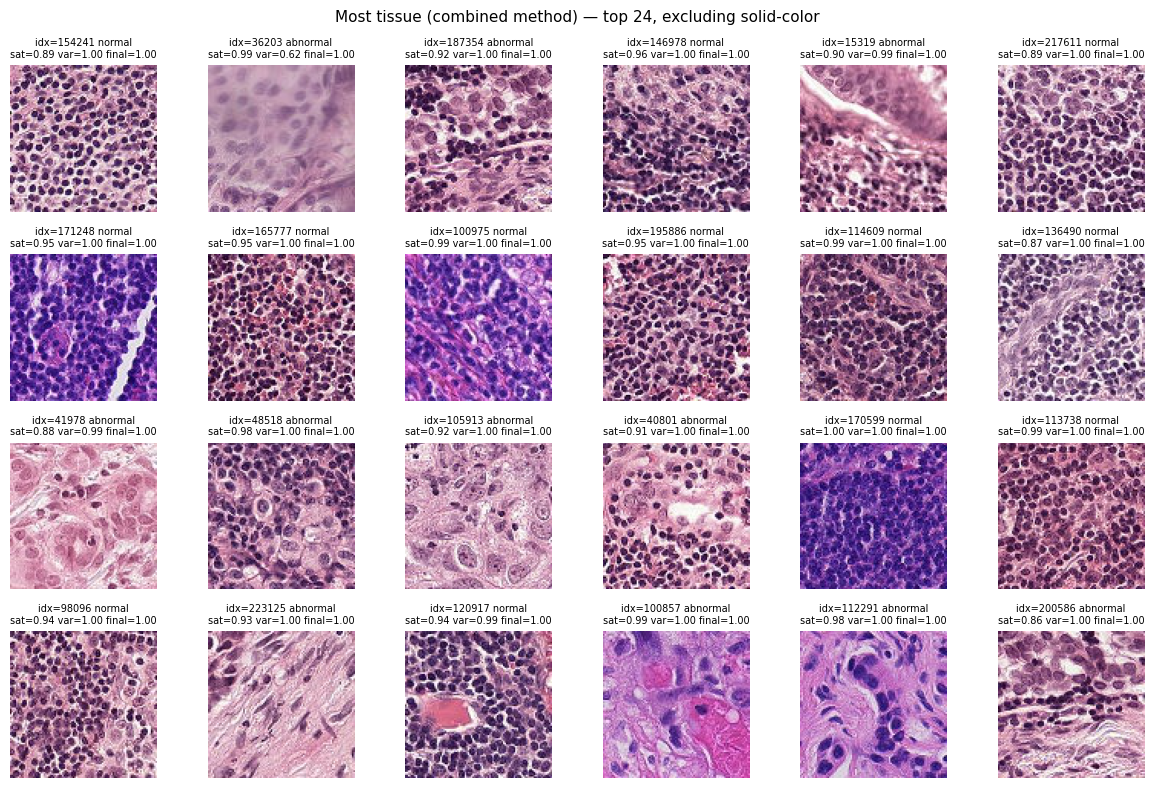

In [35]:
# Top 24 by final tissue % (excluding solid-color)
non_solid = data[~solid_color_mask]
top_combined = non_solid[np.argsort(-non_solid[:, final_col])][:24]
fig_top, axes_top = plt.subplots(4, 6, figsize=(12, 8))
for k in range(24):
    ax = axes_top.flat[k]
    idx = int(top_combined[k, idx_col])
    patch = np.asarray(train_x[idx])
    if patch.max() > 1.0: patch = np.clip(patch / 255.0, 0, 1)
    ax.imshow(patch)
    sat_p, var_p, fin_p = top_combined[k, sat_col], top_combined[k, var_col], top_combined[k, final_col]
    lab = "abnormal" if int(train_y[idx]) == 1 else "normal"
    ax.set_title(f"idx={idx} {lab}\nsat={sat_p:.2f} var={var_p:.2f} final={fin_p:.2f}", fontsize=7)
    ax.axis("off")
plt.suptitle("Most tissue (combined method) — top 24, excluding solid-color", fontsize=11)
plt.tight_layout()
plt.show()